# Modelo Variação 3: DenseNet-169

Esta variação utiliza a arquitetura **DenseNet-169** com o mesmo **Data Augmentation Robusto** da Variação 2:
- **Augmentation:** RandomResizedCrop, Rotation, Jitter, Vertical Flip e Random Erasing.
- **Épocas:** Máximo de 50 épocas.
- **Early Stopping:** Mantido (paciência = 5).
- **Arquitetura:** DenseNet-169 (Backbone 100% congelado).

In [1]:
# =========================================================
# Setup: Bibliotecas e Reprodutibilidade
# =========================================================
import os, random, warnings, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, f1_score, classification_report

import torch, torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()
print(f"Device: {device} | AMP: {use_amp}")

# Diretório para salvar os modelos
SAVE_DIR = Path("../models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda | AMP: True


In [2]:
# ============================
# Configuração do Dataset
# ============================
DATA_ROOT = Path('/home/gustavom/Documents/Orange/Brain Tumor MRI Dataset')
TRAIN_DIR = DATA_ROOT / "Training"
TEST_DIR  = DATA_ROOT / "Testing"

assert TRAIN_DIR.exists(), f"Pasta {TRAIN_DIR} não encontrada."
assert TEST_DIR.exists(), f"Pasta {TEST_DIR} não encontrada."

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Augmentation ROBUSTO para a Variação 3
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3))
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds   = datasets.ImageFolder(TEST_DIR,  transform=val_tfms)

class_names = train_ds.classes
print("Classes encontradas:", class_names)
print(f"Qtd Treino: {len(train_ds)} | Qtd Teste/Val: {len(val_ds)}")

batch_size = 32
num_workers = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

Classes encontradas: ['glioma', 'meningioma', 'notumor', 'pituitary']
Qtd Treino: 5600 | Qtd Teste/Val: 1600


In [3]:
# ============================
# Modelo: DenseNet-169 Variação 3
# ============================
weights = models.DenseNet169_Weights.IMAGENET1K_V1
model = models.densenet169(weights=weights)

# Congela TODO o backbone
for p in model.features.parameters():
    p.requires_grad = False

# Cabeça treinável
num_classes = len(class_names)
in_feats = model.classifier.in_features
model.classifier = nn.Linear(in_feats, num_classes)

model = model.to(device)

In [4]:
# ============================
# Otimizador e Early Stopping
# ============================
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, path="variation3_densenet169.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best = float("inf")
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.counter = 0
            self.best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            torch.save(self.best_state, self.path)
            return False
        else:
            self.counter += 1
            return self.counter > self.patience

early_stopper = EarlyStopping(patience=5, min_delta=1e-4, path=SAVE_DIR / "variation3_densenet169.pth")

In [5]:
# ============================
# Funções de Treino e Plot
# ============================
def run_epoch(model, loader, train=True):
    model.train(mode=train)
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    for X, y in loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(X)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                logits = model(X)
                loss = criterion(logits, y)

        preds = logits.argmax(1)
        total_loss += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    avg_loss = total_loss / total
    acc = total_correct / total
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    f1 = f1_score(y_true, y_pred, average='macro')
    return avg_loss, acc, f1, y_true, y_pred

def plot_curve(hist, k1, k2, title, ylab):
    plt.figure(figsize=(6,4))
    plt.plot(hist[k1], label=k1)
    plt.plot(hist[k2], label=k2)
    plt.xlabel("epoch"); plt.ylabel(ylab); plt.title(title); plt.legend(); plt.show()

def plot_cm(cm, classes, normalize=False, title="Confusion Matrix"):
    if normalize: cm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
    import itertools
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues); plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes)); plt.xticks(ticks, classes, rotation=45); plt.yticks(ticks, classes)
    fmt = ".2f" if normalize else "d"; thresh = cm.max()/2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), ha="center",
                 color="white" if cm[i,j] > thresh else "black")
    plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.show()

In [6]:
# ============================
# Treinamento
# ============================
EPOCHS = 50
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_f1":[]}
SAVE_PATH = SAVE_DIR / "variation3_densenet169.pth"

print(f"Iniciando treinamento (Variação 3 - {EPOCHS} épocas)...")
for e in range(1, EPOCHS+1):
    tr_loss, tr_acc, _, _, _ = run_epoch(model, train_loader, train=True)
    va_loss, va_acc, va_f1, y_true, y_pred = run_epoch(model, val_loader, train=False)

    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc); history["val_f1"].append(va_f1)

    print(f"[{e}/{EPOCHS}] train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f}")

    if early_stopper.step(va_loss, model):
        print(f"Early stopping ativado na época {e}.")
        break

Iniciando treinamento (Variação 3 - 50 épocas)...
[1/50] train_loss=0.7074 acc=0.7516 | val_loss=0.6063 acc=0.7775 f1=0.7771
[2/50] train_loss=0.4649 acc=0.8398 | val_loss=0.5109 acc=0.8163 f1=0.8131
[3/50] train_loss=0.3980 acc=0.8589 | val_loss=0.4942 acc=0.8069 f1=0.8094
[4/50] train_loss=0.3745 acc=0.8704 | val_loss=0.4547 acc=0.8325 f1=0.8324
[5/50] train_loss=0.3502 acc=0.8750 | val_loss=0.4718 acc=0.8225 f1=0.8228
[6/50] train_loss=0.3357 acc=0.8773 | val_loss=0.4774 acc=0.8294 f1=0.8297
[7/50] train_loss=0.3315 acc=0.8784 | val_loss=0.4367 acc=0.8444 f1=0.8411
[8/50] train_loss=0.3347 acc=0.8820 | val_loss=0.4255 acc=0.8419 f1=0.8409
[9/50] train_loss=0.3160 acc=0.8838 | val_loss=0.4470 acc=0.8519 f1=0.8512
[10/50] train_loss=0.3071 acc=0.8904 | val_loss=0.4605 acc=0.8281 f1=0.8300
[11/50] train_loss=0.3100 acc=0.8850 | val_loss=0.4825 acc=0.8344 f1=0.8314
[12/50] train_loss=0.3066 acc=0.8862 | val_loss=0.4753 acc=0.8375 f1=0.8361
[13/50] train_loss=0.3032 acc=0.8877 | val_loss

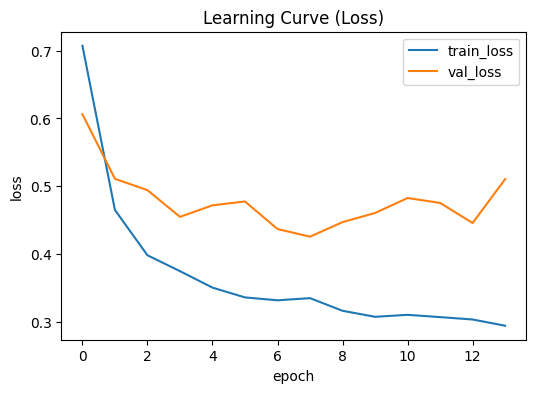

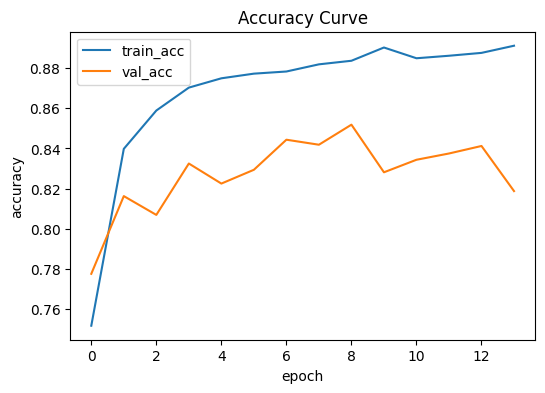

Melhor modelo carregado de ../models/variation3_densenet169.pth

Melhor F1-Score (Macro): 0.8409

Classification Report:
               precision    recall  f1-score   support

      glioma       0.83      0.78      0.80       400
  meningioma       0.74      0.74      0.74       400
     notumor       0.88      0.97      0.92       400
   pituitary       0.92      0.88      0.90       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.84      1600
weighted avg       0.84      0.84      0.84      1600



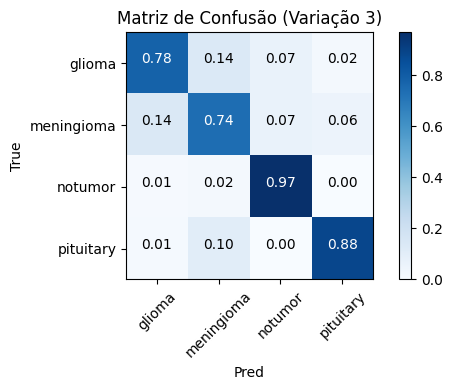

In [7]:
# ============================
# Resultados Finais
# ============================
plot_curve(history, "train_loss", "val_loss", "Learning Curve (Loss)", "loss")
plot_curve(history, "train_acc",  "val_acc",  "Accuracy Curve", "accuracy")

# Carrega o melhor e avalia uma última vez
if os.path.exists(SAVE_PATH):
    state = torch.load(SAVE_PATH, map_location=device)
    model.load_state_dict(state)
    print(f"Melhor modelo carregado de {SAVE_PATH}")

_, _, val_f1, y_true, y_pred = run_epoch(model, val_loader, train=False)

print(f"\nMelhor F1-Score (Macro): {val_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plot_cm(cm, class_names, normalize=True, title="Matriz de Confusão (Variação 3)")